Loading datasets...
Total samples: 26219
Fake news: 10236
True news: 15983

DATA EXPLORATION

Missing values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Label distribution:
label
1    15983
0    10236
Name: count, dtype: int64


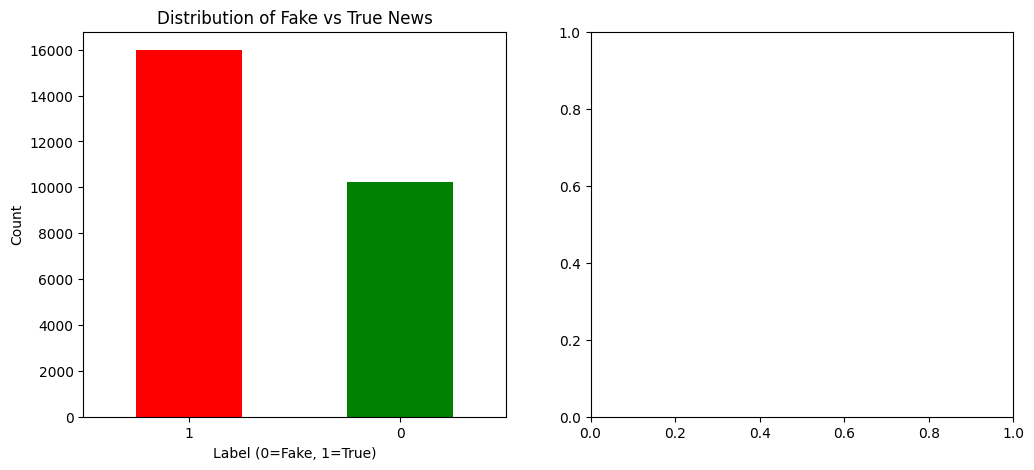

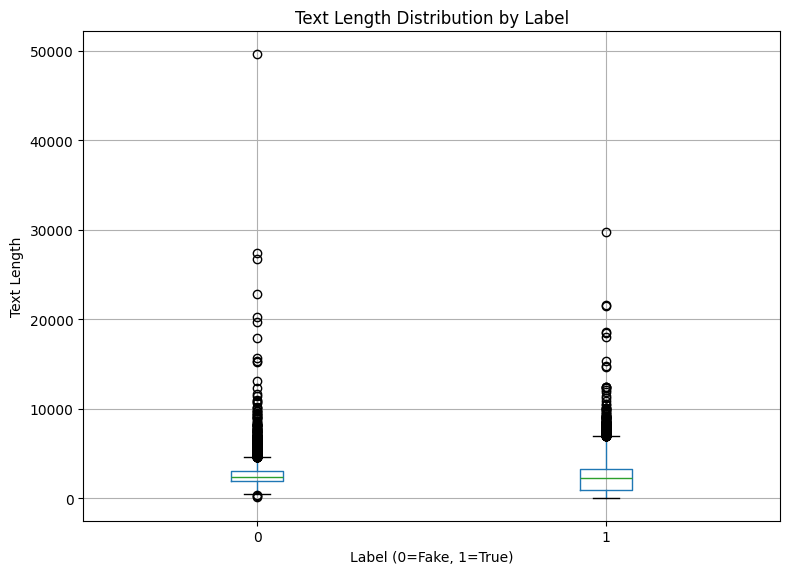


Preparing features...
Preprocessing text...

Training set size: 20975
Testing set size: 5244

Vectorizing text...

TRAINING MODELS

Training Logistic Regression...
Logistic Regression - Accuracy: 0.9912, F1 Score: 0.9928

Training Naive Bayes...
Naive Bayes - Accuracy: 0.9636, F1 Score: 0.9701

Training Linear SVM...
Linear SVM - Accuracy: 0.9964, F1 Score: 0.9970

Training Random Forest...
Random Forest - Accuracy: 0.9975, F1 Score: 0.9980

Best Model: Random Forest

MODEL EVALUATION

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      2047
        True       1.00      1.00      1.00      3197

    accuracy                           1.00      5244
   macro avg       1.00      1.00      1.00      5244
weighted avg       1.00      1.00      1.00      5244



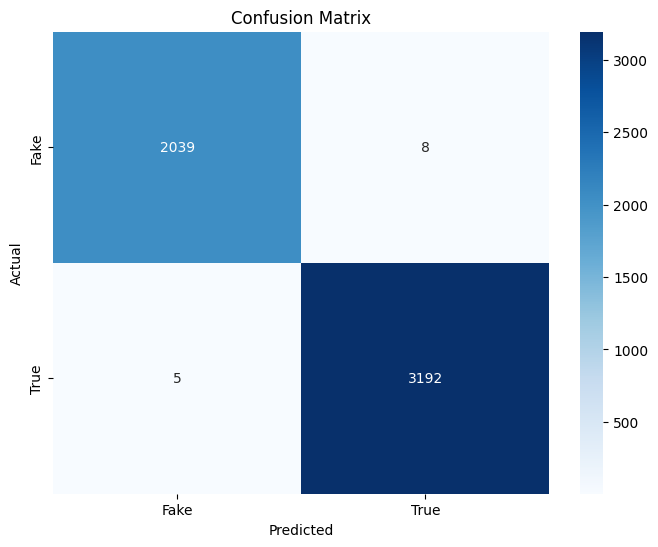


TESTING PREDICTION

Sample News: 
    Breaking: Scientists discover new planet that could support life.
    The planet is located in ...
Prediction: FAKE NEWS
Confidence: 57.00%

INTERACTIVE PREDICTION

Enter a news article to check (or 'quit' to exit):

Prediction: FAKE NEWS
Confidence: 95.00%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data (run once)
import nltk
nltk.download('stopwords', quiet=True)

class FakeNewsDetector:
    def __init__(self):
        self.vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
        self.model = None
        self.stemmer = PorterStemmer()
        self.stop_words = set(stopwords.words('english'))

    def load_data(self, fake_path='Fake.csv', true_path='True.csv'):
        """Load and combine fake and true news datasets"""
        print("Loading datasets...")

        # Load datasets
        fake_df = pd.read_csv(fake_path, engine='python', quotechar='"', doublequote=True, on_bad_lines='warn')
        true_df = pd.read_csv(true_path, engine='python', quotechar='"', doublequote=True, on_bad_lines='warn')

        # Add labels
        fake_df['label'] = 0  # Fake news
        true_df['label'] = 1  # True news

        # Combine datasets
        df = pd.concat([fake_df, true_df], ignore_index=True)

        # Shuffle the dataset
        df = df.sample(frac=1, random_state=42).reset_index(drop=True)

        print(f"Total samples: {len(df)}")
        print(f"Fake news: {len(fake_df)}")
        print(f"True news: {len(true_df)}")

        return df

    def preprocess_text(self, text):
        """Clean and preprocess text data"""
        if pd.isna(text):
            return ""

        # Convert to lowercase
        text = text.lower()

        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)

        # Remove punctuation and numbers
        text = re.sub(r'[^a-zA-Z\s]', '', text)

        # Remove extra whitespace
        text = ' '.join(text.split())

        # Tokenize and remove stopwords
        words = text.split()
        words = [self.stemmer.stem(word) for word in words if word not in self.stop_words]

        return ' '.join(words)

    def explore_data(self, df):
        """Perform exploratory data analysis"""
        print("\n" + "="*50)
        print("DATA EXPLORATION")
        print("="*50)

        # Check for missing values
        print("\nMissing values:")
        print(df.isnull().sum())

        # Label distribution
        print("\nLabel distribution:")
        print(df['label'].value_counts())

        # Visualize label distribution
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        df['label'].value_counts().plot(kind='bar', color=['red', 'green'])
        plt.title('Distribution of Fake vs True News')
        plt.xlabel('Label (0=Fake, 1=True)')
        plt.ylabel('Count')
        plt.xticks(rotation=0)

        # Text length analysis
        if 'text' in df.columns:
            df['text_length'] = df['text'].astype(str).apply(len)

            plt.subplot(1, 2, 2)
            df.boxplot(column='text_length', by='label', figsize=(8, 6))
            plt.title('Text Length Distribution by Label')
            plt.suptitle('')
            plt.xlabel('Label (0=Fake, 1=True)')
            plt.ylabel('Text Length')

        plt.tight_layout()
        plt.show()

    def prepare_features(self, df):
        """Combine text columns and prepare features"""
        print("\nPreparing features...")

        # Combine title and text (adjust column names based on your CSV structure)
        if 'title' in df.columns and 'text' in df.columns:
            df['content'] = df['title'].astype(str) + ' ' + df['text'].astype(str)
        elif 'text' in df.columns:
            df['content'] = df['text'].astype(str)
        else:
            # If columns are different, combine all text columns
            text_cols = df.select_dtypes(include=['object']).columns
            text_cols = [col for col in text_cols if col != 'label']
            df['content'] = df[text_cols].astype(str).agg(' '.join, axis=1)

        # Preprocess text
        print("Preprocessing text...")
        df['processed_content'] = df['content'].apply(self.preprocess_text)

        return df

    def train_models(self, X_train, X_test, y_train, y_test):
        """Train multiple models and compare performance"""
        print("\n" + "="*50)
        print("TRAINING MODELS")
        print("="*50)

        models = {
            'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
            'Naive Bayes': MultinomialNB(),
            'Linear SVM': LinearSVC(max_iter=1000, random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
        }

        results = {}

        for name, model in models.items():
            print(f"\nTraining {name}...")
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            accuracy = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)

            results[name] = {
                'model': model,
                'accuracy': accuracy,
                'f1_score': f1,
                'predictions': y_pred
            }

            print(f"{name} - Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}")

        # Select best model
        best_model_name = max(results, key=lambda x: results[x]['f1_score'])
        self.model = results[best_model_name]['model']

        print(f"\n{'='*50}")
        print(f"Best Model: {best_model_name}")
        print(f"{'='*50}")

        return results, best_model_name

    def evaluate_model(self, y_test, y_pred):
        """Evaluate model performance with detailed metrics"""
        print("\n" + "="*50)
        print("MODEL EVALUATION")
        print("="*50)

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=['Fake', 'True']))

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Fake', 'True'],
                    yticklabels=['Fake', 'True'])
        plt.title('Confusion Matrix')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()

        return cm

    def predict_news(self, text):
        """Predict if a news article is fake or true"""
        if self.model is None:
            raise ValueError("Model not trained yet!")

        # Preprocess the input text
        processed_text = self.preprocess_text(text)

        # Transform using the vectorizer
        text_vector = self.vectorizer.transform([processed_text])

        # Make prediction
        prediction = self.model.predict(text_vector)[0]

        # Get probability if available
        if hasattr(self.model, 'predict_proba'):
            probability = self.model.predict_proba(text_vector)[0]
            confidence = probability[prediction]
        else:
            confidence = None

        result = "TRUE NEWS" if prediction == 1 else "FAKE NEWS"

        return result, confidence

    def run_pipeline(self, fake_path='Fake.csv', true_path='True.csv'):
        """Run the complete fake news detection pipeline"""
        # Load data
        df = self.load_data(fake_path, true_path)

        # Explore data
        self.explore_data(df)

        # Prepare features
        df = self.prepare_features(df)

        # Split data
        X = df['processed_content']
        y = df['label']

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        print(f"\nTraining set size: {len(X_train)}")
        print(f"Testing set size: {len(X_test)}")

        # Vectorize text
        print("\nVectorizing text...")
        X_train_vec = self.vectorizer.fit_transform(X_train)
        X_test_vec = self.vectorizer.transform(X_test)

        # Train models
        results, best_model_name = self.train_models(
            X_train_vec, X_test_vec, y_train, y_test
        )

        # Evaluate best model
        best_predictions = results[best_model_name]['predictions']
        self.evaluate_model(y_test, best_predictions)

        return results


# Main execution
if __name__ == "__main__":
    # Initialize detector
    detector = FakeNewsDetector()

    # Run the complete pipeline
    # Make sure 'Fake.csv' and 'True.csv' are in the same directory
    results = detector.run_pipeline('Fake.csv', 'True.csv')

    # Test prediction with sample text
    print("\n" + "="*50)
    print("TESTING PREDICTION")
    print("="*50)

    sample_news = """
    Breaking: Scientists discover new planet that could support life.
    The planet is located in a nearby solar system and has conditions
    similar to Earth.
    """

    prediction, confidence = detector.predict_news(sample_news)
    print(f"\nSample News: {sample_news[:100]}...")
    print(f"Prediction: {prediction}")
    if confidence:
        print(f"Confidence: {confidence:.2%}")

    # Interactive prediction
    print("\n" + "="*50)
    print("INTERACTIVE PREDICTION")
    print("="*50)
    print("\nEnter a news article to check (or 'quit' to exit):")

    while True:
        user_input = input("\nNews text: ")
        if user_input.lower() == 'quit':
            break

        if user_input.strip():
            prediction, confidence = detector.predict_news(user_input)
            print(f"\nPrediction: {prediction}")
            if confidence:
                print(f"Confidence: {confidence:.2%}")